# 02 · Model Açıklanabilirliği (SHAP)

**Amaç:** Final modelin (LightGBM · alt örnekleme, yalnızca eğitim bölmesiyle eğitildi) genel
olarak hangi bilgilere dayandığını ve tek tek alarmların neden verildiğini göstermek.

**Veri:** Doğrulama bölmesi. Test bölmesi Faz 3.5'te bir kez değerlendirildi; burada
kullanılmaz. Örnek vakalar, Faz 3.4 hata analiziyle aynı alarmlardan (Mayıs–Haziran, her ay
önceki aylarla kalibre edilmiş) seçilir. Üretmek için: `make threshold && make explain`.

**Okuma notu:** SHAP değerleri ham model skorunu (**log-oran**) açıklar; olasılık değil.
Kalibrasyon skoru monoton biçimde dönüştürdüğü için nedenlerin sıralaması değişmez. Aynı bilgiyi
taşıyan özellikler anlam gruplarına toplanır (ör. `amt` + `log_amt` → "tutar").

In [1]:
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from card_fraud_detection.config import REPORTS_DIR, TARGET
from card_fraud_detection.evaluation.error_analysis import (
    after_fraud, burst_position, out_of_sample_alerts, outcome,
)
from card_fraud_detection.evaluation.metrics import assign_bursts
from card_fraud_detection.features.build import FEATURES
from card_fraud_detection.models.explain import (
    GROUPS, base_value, explainer, group_contributions, shap_values, top_reasons,
)
from card_fraud_detection.models.threshold import DECISION_PATH, MODEL_PATH
from card_fraud_detection.models.train import load_splits

warnings.filterwarnings("ignore", message="LightGBM binary classifier with TreeExplainer")
FIG_DIR = REPORTS_DIR / "figures"
FRAUD, NORMAL = "#eb6834", "#2a78d6"          # EDA ile aynı renk anlamı
INK2, MUTED, GRID, AXIS, SURFACE = "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 90, "savefig.dpi": 130, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2, "font.family": "DejaVu Sans",
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", facecolor=SURFACE)

bundle = joblib.load(MODEL_PATH)
decision = json.loads(DECISION_PATH.read_text(encoding="utf-8"))
_, valid = load_splits(FEATURES)
valid["patlama"] = assign_bursts(valid["cc_num"], valid["trans_date_trans_time"], valid[TARGET])
valid["patlama_sira"] = burst_position(valid)
score = bundle["model"].predict_proba(valid[FEATURES])[:, 1]
f = out_of_sample_alerts(valid, score, decision)
f["sonuç"] = outcome(f)
f["sonuç"].value_counts()

sonuç
doğru sessizlik    131065
yakalandı             768
yanlış alarm          164
kaçtı                  93
Name: count, dtype: int64

## 1. Açıklanacak örneklem

In [2]:
# Tüm dolandırıcılıklar ve yanlış alarmlar + 15.000 rastgele doğru sessizlik
rng = np.random.default_rng(42)
quiet = f.index[f["sonuç"] == "doğru sessizlik"]
sample_idx = f.index[f["sonuç"] != "doğru sessizlik"].union(
    pd.Index(rng.choice(quiet, 15_000, replace=False)))
x = f.loc[sample_idx, FEATURES]
expl = explainer(bundle["model"])
sv = shap_values(expl, x)
contrib = group_contributions(sv)
raw = bundle["model"].predict_proba(x, raw_score=True)
print(f"{len(x):,} işlem · toplanabilirlik hatası (en büyük): "
      f"{np.abs(sv.sum(axis=1) + base_value(expl) - raw).max():.2e}")

16,025 işlem · toplanabilirlik hatası (en büyük): 1.71e-13


## 2. Model genel olarak neye dayanıyor?

,tüm örneklem,dolandırıcılıklar
tutar,1.928,7.996
saat,1.346,2.792
son 24 saat,1.297,5.721
kategoriye göre tutar,0.868,2.210
son 7 gün,0.586,1.515
kart geçmişi uzunluğu,0.575,0.610
önceki işlemden süre,0.516,0.511
kategori,0.511,1.207
karta göre tutar,0.393,2.007
son 1 saat,0.207,1.049


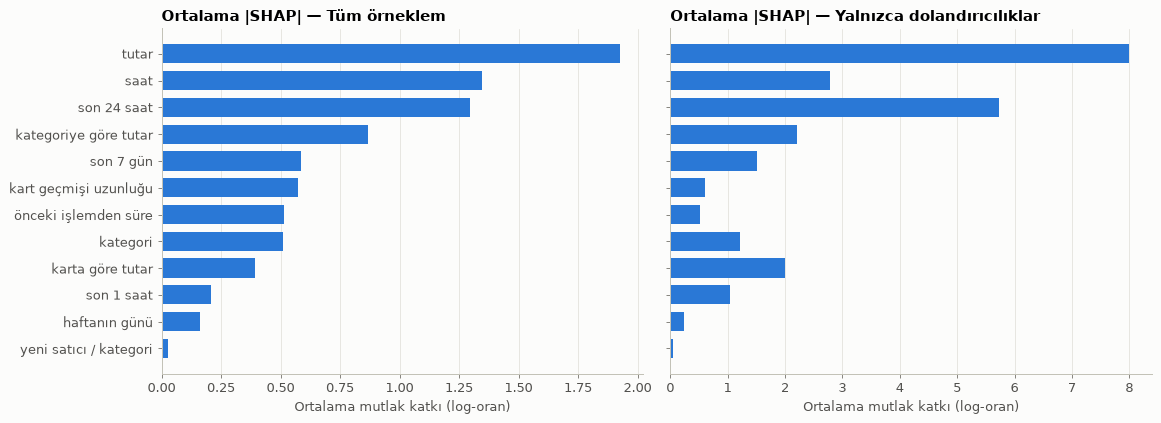

In [3]:
imp = contrib.abs().mean().sort_values()
fraud_imp = contrib.loc[f.loc[sample_idx, TARGET] == 1].abs().mean().reindex(imp.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, vals, title in [(axes[0], imp, "Tüm örneklem"),
                        (axes[1], fraud_imp, "Yalnızca dolandırıcılıklar")]:
    ax.barh(vals.index, vals.values, color=NORMAL, height=0.72)
    ax.set(title=f"Ortalama |SHAP| — {title}", xlabel="Ortalama mutlak katkı (log-oran)")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "4_shap_onem")
pd.DataFrame({"tüm örneklem": imp, "dolandırıcılıklar": fraud_imp}).sort_values(
    "tüm örneklem", ascending=False).round(3)

**Bulgular**
- Model en çok **tutara** dayanıyor; ardından **saat** ve **son 24 saatteki harcama** geliyor.
  Dolandırıcılıklarda son 24 saat ikinci sıraya çıkıyor (5,7): patlamanın devamını bu grup
  yakalıyor. Sıralama, Faz 3.1'deki kazanç (gain) önemleriyle ve EDA bulgularıyla uyumlu.
- **"Yeni satıcı / kategori" neredeyse hiç katkı vermiyor** (0,03). Simülatörde müşteriler
  satıcıları rastgele seçtiği için bu sinyal yok; ileride özellik listesinden çıkarılabilir.

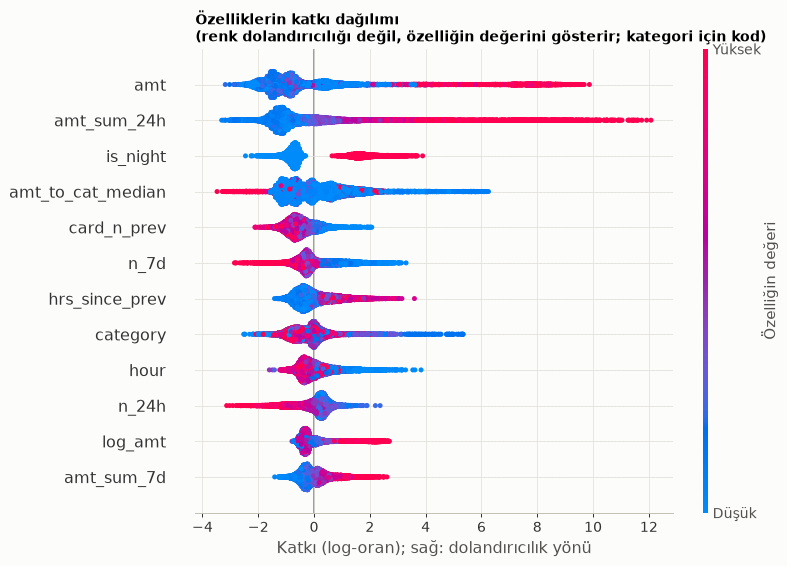

In [4]:
top = sv.abs().mean().sort_values(ascending=False).index[:12]
x_plot = x[top].copy()
x_plot["category"] = x_plot["category"].cat.codes if "category" in x_plot else None
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(sv[top].to_numpy(), x_plot.astype(float), show=False, max_display=12,
                  plot_size=None)
fig = plt.gcf()
fig.axes[0].set_xlabel("Katkı (log-oran); sağ: dolandırıcılık yönü")
fig.axes[-1].set_ylabel("Özelliğin değeri")
fig.axes[-1].set_yticklabels(["Düşük", "Yüksek"])
fig.axes[0].set_title("Özelliklerin katkı dağılımı\n(renk dolandırıcılığı değil, özelliğin "
                      "değerini gösterir; kategori için kod)", loc="left", fontsize=11,
                      fontweight="bold")
save(plt.gcf(), "4_shap_dagilim")
plt.show()

**Bulgular**
- Beklenen yönler: Yüksek tutar, yüksek 24 saatlik harcama ve gece saati skoru yukarı itiyor.
  Son 24 saatteki **işlem sayısının** yüksek olması ise skoru aşağı itiyor: Çok işlem yapan
  kartlar çoğunlukla normal (EDA §4 ile uyumlu). Kartın geçmişi uzadıkça skor da düşüyor.
- **Tek özelliğin katkısı tek başına yorumlanmamalı.** `amt_to_cat_median`'ın yüksek değerleri
  negatif katkı alıyor; ilk bakışta ters görünüyor. Birbiriyle ilişkili özellikler (`amt`,
  `log_amt`, oranlar) katkıyı ağaçlarda kendi aralarında paylaşıyor. Bu yüzden açıklamalar ve
  API'nin nedenleri **anlam grupları** üzerinden verilir; grup düzeyindeki tablo tutarlıdır.

## 3. Tutarın anlamı kategoriye göre değişiyor mu?

EDA §2, çevrim içi alışverişte dolandırıcılığın normalden ~120 kat büyük, akaryakıtta ise
küçük olduğunu göstermişti. Modelin bunu öğrenip öğrenmediği, tutar grubunun katkısının
kategoriye göre nasıl değiştiğinden okunabilir.

bant,<20,20–100,100–300,300–800,≥800
kategori,,,,,
gas_transport,7.72,-3.12,-1.97,NaN,NaN
shopping_net,-1.29,-1.55,-1.44,3.46,11.63


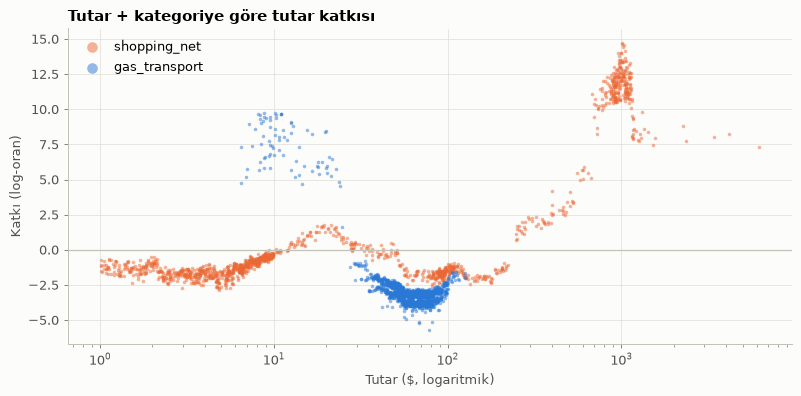

In [5]:
dep = pd.DataFrame({"amt": x["amt"], "kategori": x["category"].astype(str),
                    "katkı": contrib["tutar"] + contrib["kategoriye göre tutar"]})
fig, ax = plt.subplots(figsize=(9, 4.5))
for cat, color in [("shopping_net", FRAUD), ("gas_transport", NORMAL)]:
    d = dep[dep["kategori"] == cat]
    ax.scatter(d["amt"], d["katkı"], s=8, alpha=0.5, color=color, label=cat, linewidths=0)
ax.axhline(0, color=AXIS, lw=1)
ax.set_xscale("log")
ax.set(title="Tutar + kategoriye göre tutar katkısı", xlabel="Tutar ($, logaritmik)",
       ylabel="Katkı (log-oran)")
ax.legend(loc="upper left", frameon=False, markerscale=3)
fig.tight_layout()
save(fig, "4_shap_tutar_kategori")
dep.assign(bant=pd.cut(dep["amt"], [0, 20, 100, 300, 800, np.inf],
                       labels=["<20", "20–100", "100–300", "300–800", "≥800"], right=False)) \
   .query("kategori in ['shopping_net', 'gas_transport']") \
   .groupby(["kategori", "bant"], observed=True)["katkı"].median().unstack().round(2)

**Bulgular**
- Model, EDA'daki "tutarın anlamı kategoriye göre tersine dönüyor" bulgusunu öğrenmiş:
  - **Akaryakıt:** $20'nin altındaki işlemler dolandırıcılık yönünde güçlü katkı alıyor
    (medyan +7,7); $20-100 arası normal yönünde (−3,1).
  - **Çevrim içi alışveriş:** $300'ün altı normal yönünde; $300-800 +3,5; $800 ve üzeri +11,6.
- Bu, simülatörün kategoriye özgü dolandırıcılık tutar bantlarının öğrenildiğini gösteriyor.
  Gerçek veride bu kadar keskin bantlar beklenmez (README sınırlamaları).

## 4. Tek tek vakalar: neden alarm verildi (ya da verilmedi)?

,vaka,neden,katkı
0,Yakalanan: patlamanın ilk işlemi,"Tutar: $287,80",9.87
1,Yakalanan: patlamanın ilk işlemi,"Tutar, grocery_pos kategorisindeki olağan tuta...",6.25
2,Yakalanan: patlamanın ilk işlemi,Kategori: grocery_pos,2.62
3,Yanlış alarm (en yüksek olasılıklı),"Son 24 saatte kartta 6 işlem, toplam $4.423",9.69
4,Yanlış alarm (en yüksek olasılıklı),"Tutar: $3.404,22",7.95
5,Yanlış alarm (en yüksek olasılıklı),"Tutar, kartın geçmiş ortalamasının 60,1 katı",3.29
6,Kaçan: pahalı ama sakin (Faz 3.4),"Tutar: $780,14",9.02
7,Kaçan: pahalı ama sakin (Faz 3.4),"Tutar, kartın geçmiş ortalamasının 13,6 katı",2.63
8,Kaçan: pahalı ama sakin (Faz 3.4),"Son 1 saatte kartta 1 işlem, toplam $21",1.01


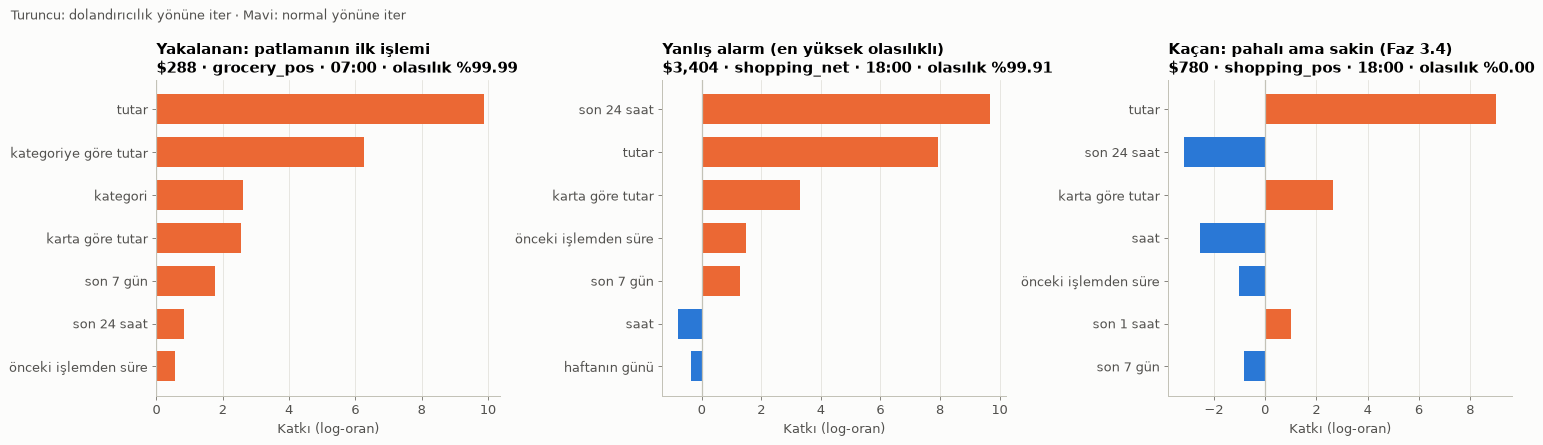

In [6]:
def case_frame(idx):
    return contrib.loc[idx].sort_values(key=np.abs, ascending=False)

caught_first = f[(f["sonuç"] == "yakalandı") & (f["patlama_sira"] == 1)]
cases = {
    "Yakalanan: patlamanın ilk işlemi": caught_first.loc[caught_first["p"].idxmax()].name,
    "Yanlış alarm (en yüksek olasılıklı)": f[f["sonuç"] == "yanlış alarm"]["p"].idxmax(),
    "Kaçan: pahalı ama sakin (Faz 3.4)": f[(f["sonuç"] == "kaçtı") & (f["amt"] >= 200)]
        ["amt_to_cat_median"].idxmax(),
}
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=False)
rows = []
for ax, (title, idx) in zip(axes, cases.items()):
    c = case_frame(idx).head(7)[::-1]
    ax.barh(c.index, c.values, color=[FRAUD if v > 0 else NORMAL for v in c.values],
            height=0.7)
    ax.axvline(0, color=AXIS, lw=1)
    r = f.loc[idx]
    ax.set(title=f"{title}\n${r['amt']:,.0f} · {r['category']} · {int(r['hour']):02d}:00 · "
                 f"olasılık %{100 * r['p']:.2f}", xlabel="Katkı (log-oran)")
    ax.title.set_fontsize(10)
    ax.grid(axis="y", visible=False)
    for reason in top_reasons(contrib.loc[idx], f.loc[idx]):
        rows.append({"vaka": title, "neden": reason["aciklama"],
                     "katkı": round(reason["katki"], 2)})
fig.suptitle("Turuncu: dolandırıcılık yönüne iter · Mavi: normal yönüne iter",
             x=0.01, ha="left", fontsize=10, color=INK2)
fig.tight_layout()
save(fig, "4_shap_ornekler")
pd.DataFrame(rows)

**Bulgular**
- **Yakalanan (patlamanın ilk işlemi, $288, grocery_pos, 07:00):** Kartın geçmişinde henüz
  hareket yok; alarmı tutar (+9,9), tutarın kategoriye göre büyüklüğü (+6,3) ve kategori
  (+2,6) veriyor. Faz 2.3'te lojistik regresyonun kaçırdığı "sakin ilk işlem"i ağaç modeli
  tutar × kategori etkileşimiyle yakalıyor.
- **Yanlış alarm ($3.404, shopping_net, 18:00):** Kart son 24 saatte 6 işlemde $4.423
  harcamış (+9,7), tutar kartın ortalamasının 60 katı. Gerçek bir işlem, ama patlamaya birebir
  benziyor; bu tür vakalar için analist incelemesi zaten doğru süreç.
- **Kaçan ($780, shopping_pos, 18:00):** Tutar skoru +9 yukarı itiyor, ama işlem **gündüz**
  (saat −2,6) ve son 24 saat **sakin** (−3,2); toplamda olasılık ~%0. Faz 3.4'teki kör
  noktanın mekanizması bu: Model "dolandırıcılık = gece + patlama" kalıbını öğrenmiş; gündüz
  yapılan, patlama eşlik etmeyen pahalı dolandırıcılığı geçiriyor.
- API yalnızca alarm alan işlemler için nedenleri gösterecek; nedenler yalnızca skoru yukarı
  iten (pozitif katkılı) gruplardan seçilir.

## 5. Özet

| Soru | Cevap |
|---|---|
| Model neye dayanıyor? | Tutar, saat, son 24 saatteki harcama, tutarın kategoriye göre büyüklüğü |
| EDA bulgularını öğrenmiş mi? | Evet: tutarın anlamı kategoriye göre değişiyor, gece ve patlama riskli, yoğun kullanılan kart normal |
| İlk işlemi nasıl yakalıyor? | Kart geçmişi sakin olsa da tutar × kategori etkileşimiyle |
| Neden pahalı dolandırıcılık kaçıyor? | Gündüz ve sakin kart geçmişi, yüksek tutarın etkisini sıfırlıyor |
| Gereksiz özellik var mı? | "Yeni satıcı / kategori" katkı vermiyor (simülatörde sinyal yok) |
| API'nin nedenleri nereden gelir? | `models/explain.py`: anlam gruplarının pozitif SHAP katkıları, Türkçe cümle |